<a href="https://www.kaggle.com/code/mehulkumar99/spider-question-to-sql-query?scriptVersionId=314183440" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Read the detailed explanation and discussion for this notebook here: [NL2SQL Blog](https://www.kaggle.com/code/mehulkumar99/blog-question-to-sql-query)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# # Let Kaggle's existing torch stay untouched
# # Just install unsloth against whatever torch is already there
# !pip install unsloth -q
# !pip install --upgrade --force-reinstall --no-cache-dir --no-deps unsloth unsloth_zoo -q

In [3]:
!wget -qO- https://raw.githubusercontent.com/unslothai/unsloth/main/unsloth/_auto_install.py | python -
# It prints the exact pip command for your environment — copy and run that command

pip install --upgrade pip && pip install --no-deps git+https://github.com/unslothai/unsloth-zoo.git && pip install "unsloth[cu128-torch2100] @ git+https://github.com/unslothai/unsloth.git" --no-build-isolation


In [4]:
import subprocess
import sys
import os

# List all your required packages here
packages = [
    "bitsandbytes", 
    "transformers", 
    "accelerate", 
    "peft", 
    "trl==0.15.2", 
    "datasets", 
    "pandas", 
    "matplotlib", 
    "seaborn", 
    "hf_transfer"
]

# Install everything using standard Python logic
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)

# unsloth installed separately — no-deps to prevent it pulling a conflicting torch
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "--no-cache-dir", "--no-deps",
    "unsloth", "unsloth_zoo"
])

# Enable high-speed Hugging Face transfers
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.9/318.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 76.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 142.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 393.6 MB/s eta 0:00:00


In [5]:
subprocess.check_call([
    sys.executable, "-m", "pip", "freeze"
], stdout=open("requirements_frozen.txt", "w"))

0

In [6]:
import os
import torch
import gc

# The fix you requested
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"


def clear_vram():
    gc.collect()
    torch.cuda.empty_cache()
    print("VRAM Cleared and Memory Management Updated.")

clear_vram()

VRAM Cleared and Memory Management Updated.


In [7]:
import torch
import transformers
# import bitsandbytes as bnb
import peft

print(f"transformers : {transformers.__version__}")
# print(f"bitsandbytes : {bnb.__version__}")
print(f"peft         : {peft.__version__}")
print(f"torch        : {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name     : {torch.cuda.get_device_name(0)}")

transformers : 5.0.0
peft         : 0.18.1
torch        : 2.10.0+cu128
GPU available: True
GPU name     : Tesla T4


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer # Autokenizer is a class of the transformers library as it starts with capital letter.
"""Autotokenizer is a class in transformers library responsible for tokenization. """

'Autotokenizer is a class in transformers library responsible for tokenization. '

**Why the "Auto" part is awesome**
Every AI model has its own unique vocabulary and its own specific way of slicing up words. For example, the way a Llama model turns text into numbers is completely different from how a GPT model does it.

If you had to look up and load the specific tokenizer for every single model manually, it would be a headache. The AutoTokenizer is smart. You just give it the name of the model you want to use, and it automatically goes and fetches the correct, matching tokenizer for that specific model.

# HANDLING THE TRAINING AND VALIDATION EXAMPLES

In [9]:
from datasets import load_dataset #loaded into the cpu. # dataset is a library and load_dataset is a function (as it has lowercase with underscore)

dataset = load_dataset("spider")
print(dataset)
# Train: 7000 examples, Validation: 1034 examples

README.md: 0.00B [00:00, ?B/s]

spider/train-00000-of-00001.parquet:   0%|          | 0.00/831k [00:00<?, ?B/s]

spider/validation-00000-of-00001.parquet:   0%|          | 0.00/126k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1034 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['db_id', 'query', 'question', 'query_toks', 'query_toks_no_value', 'question_toks'],
        num_rows: 7000
    })
    validation: Dataset({
        features: ['db_id', 'query', 'question', 'query_toks', 'query_toks_no_value', 'question_toks'],
        num_rows: 1034
    })
})


In [10]:
ex = dataset['validation'][0]
print("DB ID:", ex['db_id'])
print("\nQUESTION:", ex['question'])
print("\nQUERY:", ex['query'])
print("\nQUERY TOKS:", ex['query_toks'])
print("\nQUERY TOKS NO VALUE:", ex['query_toks_no_value'])
print("\nQUESTION TOKS:", ex['question_toks'])

DB ID: concert_singer

QUESTION: How many singers do we have?

QUERY: SELECT count(*) FROM singer

QUERY TOKS: ['SELECT', 'count', '(', '*', ')', 'FROM', 'singer']

QUERY TOKS NO VALUE: ['select', 'count', '(', '*', ')', 'from', 'singer']

QUESTION TOKS: ['How', 'many', 'singers', 'do', 'we', 'have', '?']


In [11]:
print(dataset['validation'][0].items())

dict_items([('db_id', 'concert_singer'), ('query', 'SELECT count(*) FROM singer'), ('question', 'How many singers do we have?'), ('query_toks', ['SELECT', 'count', '(', '*', ')', 'FROM', 'singer']), ('query_toks_no_value', ['select', 'count', '(', '*', ')', 'from', 'singer']), ('question_toks', ['How', 'many', 'singers', 'do', 'we', 'have', '?'])])


In [12]:
validation_df = pd.DataFrame(dataset['validation'])
validation_df.head(10)

,db_id,query,question,query_toks,query_toks_no_value,question_toks
0,concert_singer,SELECT count(*) FROM singer,How many singers do we have?,"[SELECT, count, (, *, ), FROM, singer]","[select, count, (, *, ), from, singer]","[How, many, singers, do, we, have, ?]"
1,concert_singer,SELECT count(*) FROM singer,What is the total number of singers?,"[SELECT, count, (, *, ), FROM, singer]","[select, count, (, *, ), from, singer]","[What, is, the, total, number, of, singers, ?]"
2,concert_singer,"SELECT name , country , age FROM singer ORDE...","Show name, country, age for all singers ordere...","[SELECT, name, ,, country, ,, age, FROM, singe...","[select, name, ,, country, ,, age, from, singe...","[Show, name, ,, country, ,, age, for, all, sin..."
3,concert_singer,"SELECT name , country , age FROM singer ORDE...","What are the names, countries, and ages for ev...","[SELECT, name, ,, country, ,, age, FROM, singe...","[select, name, ,, country, ,, age, from, singe...","[What, are, the, names, ,, countries, ,, and, ..."
4,concert_singer,"SELECT avg(age) , min(age) , max(age) FROM s...","What is the average, minimum, and maximum age ...","[SELECT, avg, (, age, ), ,, min, (, age, ), ,,...","[select, avg, (, age, ), ,, min, (, age, ), ,,...","[What, is, the, average, ,, minimum, ,, and, m..."
5,concert_singer,"SELECT avg(age) , min(age) , max(age) FROM s...","What is the average, minimum, and maximum age ...","[SELECT, avg, (, age, ), ,, min, (, age, ), ,,...","[select, avg, (, age, ), ,, min, (, age, ), ,,...","[What, is, the, average, ,, minimum, ,, and, m..."
6,concert_singer,"SELECT song_name , song_release_year FROM sin...",Show the name and the release year of the song...,"[SELECT, song_name, ,, song_release_year, FROM...","[select, song_name, ,, song_release_year, from...","[Show, the, name, and, the, release, year, of,..."
7,concert_singer,"SELECT song_name , song_release_year FROM sin...",What are the names and release years for all t...,"[SELECT, song_name, ,, song_release_year, FROM...","[select, song_name, ,, song_release_year, from...","[What, are, the, names, and, release, years, f..."
8,concert_singer,SELECT DISTINCT country FROM singer WHERE age ...,What are all distinct countries where singers ...,"[SELECT, DISTINCT, country, FROM, singer, WHER...","[select, distinct, country, from, singer, wher...","[What, are, all, distinct, countries, where, s..."
9,concert_singer,SELECT DISTINCT country FROM singer WHERE age ...,What are the different countries with singers...,"[SELECT, DISTINCT, country, FROM, singer, WHER...","[select, distinct, country, from, singer, wher...","[What, are, the, different, countries, with, s..."


How it behaves differently with slicingHugging Face datasets have a slightly unique behavior compared to standard Python lists. Depending on how you access the data, the return type changes:

Single Index: dataset['train'][0] $\rightarrow$ Returns a Dictionary (the row).

Slice: dataset['train'][0:5] $\rightarrow$ Returns a Dictionary of Lists (the keys are column names, the values are lists of 5 items).

Column Name: dataset['train']['question'] $\rightarrow$ Returns a List of all questions in the entire split

In [13]:
print(dataset['validation'][3].items())

dict_items([('db_id', 'concert_singer'), ('query', 'SELECT name ,  country ,  age FROM singer ORDER BY age DESC'), ('question', 'What are the names, countries, and ages for every singer in descending order of age?'), ('query_toks', ['SELECT', 'name', ',', 'country', ',', 'age', 'FROM', 'singer', 'ORDER', 'BY', 'age', 'DESC']), ('query_toks_no_value', ['select', 'name', ',', 'country', ',', 'age', 'from', 'singer', 'order', 'by', 'age', 'desc']), ('question_toks', ['What', 'are', 'the', 'names', ',', 'countries', ',', 'and', 'ages', 'for', 'every', 'singer', 'in', 'descending', 'order', 'of', 'age', '?'])])


In [14]:
dic ={}
for i in range(10):
  dic[i]= dic.get(i,i)+1
dic.items()

dict_items([(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10)])

In [15]:
ex = dataset['validation'][2]
for k, v in ex.items():
    print(f"\n--- {k} ---")
    print(v)


--- db_id ---
concert_singer

--- query ---
SELECT name ,  country ,  age FROM singer ORDER BY age DESC

--- question ---
Show name, country, age for all singers ordered by age from the oldest to the youngest.

--- query_toks ---
['SELECT', 'name', ',', 'country', ',', 'age', 'FROM', 'singer', 'ORDER', 'BY', 'age', 'DESC']

--- query_toks_no_value ---
['select', 'name', ',', 'country', ',', 'age', 'from', 'singer', 'order', 'by', 'age', 'desc']

--- question_toks ---
['Show', 'name', ',', 'country', ',', 'age', 'for', 'all', 'singers', 'ordered', 'by', 'age', 'from', 'the', 'oldest', 'to', 'the', 'youngest', '.']


converting the dataset in to pd.DatraFrame is useful for visualization of the dataset

<class 'pandas.core.series.Series'>
JOIN         2783
GROUP BY     1775
ORDER BY     1628
LIMIT        1107
HAVING        427
INTERSECT     250
EXCEPT        209
UNION          67
END AS         36
CASE            4
NESTED          0
dtype: int64


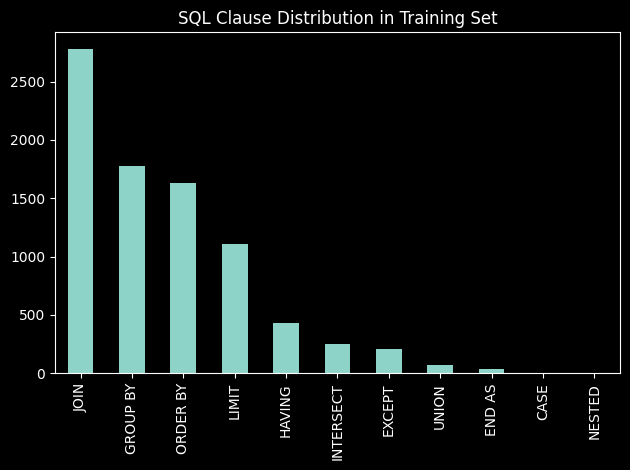

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('dark_background')

train_df = pd.DataFrame(dataset['train'])

# Count SQL keywords as a complexity proxy
keywords = ['JOIN', 'GROUP BY', 'ORDER BY', 'HAVING', 'INTERSECT', 'UNION', 'EXCEPT', 'LIMIT', 'NESTED','END AS', 'CASE']

for kw in keywords:
    train_df[kw] = train_df['query'].str.upper().str.contains(kw) # use of vectorization, means the operations are done to all the rows at once

train_df['#joins'] = train_df['query'].str.upper().str.split().apply(lambda x: x.count('JOIN'))
keyword_counts = train_df[keywords].sum().sort_values(ascending=False)
print(type(keyword_counts))
print(keyword_counts)

keyword_counts.plot(kind='bar', title='SQL Clause Distribution in Training Set')
plt.tight_layout()
plt.show()

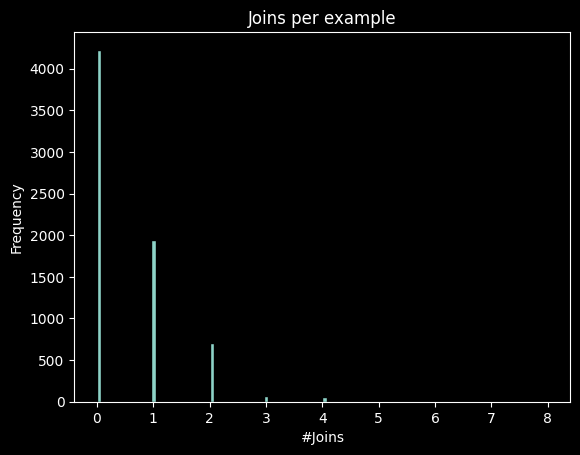

mean count of joins : 0.5418571428571428


In [17]:
# understanding the distribution of joins
joins = train_df['#joins'].tolist()



# Create the histogram
plt.hist(joins, bins=100, edgecolor='black')

# Add labels and title
plt.title('Joins per example')
plt.xlabel('#Joins')
plt.ylabel('Frequency')

# Display the plot
plt.show()
print(f'mean count of joins : {np.mean(joins)}')

JOIN         408
GROUP BY     277
ORDER BY     237
LIMIT        189
HAVING        79
INTERSECT     40
EXCEPT        31
END AS        20
UNION         11
CASE           4
NESTED         0
dtype: int64
<class 'pandas.core.series.Series'>


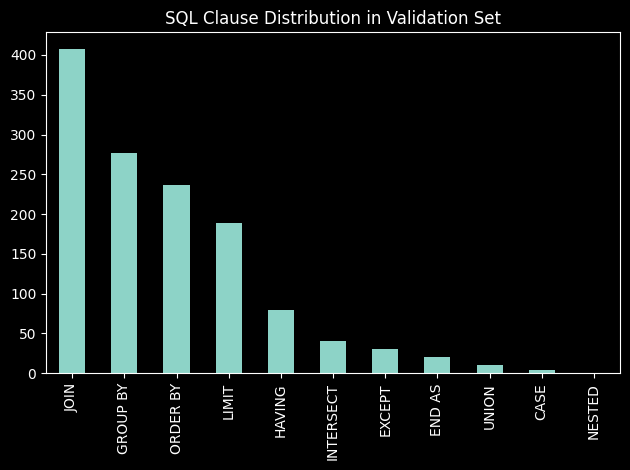

In [18]:
#distribution of keywords in validation set
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('dark_background')

validation_df = pd.DataFrame(dataset['validation'])

# Count SQL keywords as a complexity proxy
keywords = ['JOIN', 'GROUP BY', 'ORDER BY', 'HAVING', 'INTERSECT', 'UNION', 'EXCEPT', 'LIMIT', 'NESTED','END AS', 'CASE']

for kw in keywords:
    validation_df[kw] = validation_df['query'].str.upper().str.contains(kw)

keyword_counts = validation_df[keywords].sum().sort_values(ascending=False)
print(keyword_counts)
print(type(keyword_counts))

keyword_counts.plot(kind='bar', title='SQL Clause Distribution in Validation Set')
plt.tight_layout()
plt.show()

The training and validation have similar count of the keywords showing similar distribution in both

In [19]:
validation_df.iloc[-10]

db_id                                                             singer
query                  SELECT T1.Name ,  sum(T2.Sales) FROM singer AS...
question               Show the names of singers and the total sales ...
query_toks             [SELECT, T1.Name, ,, sum, (, T2.Sales, ), FROM...
query_toks_no_value    [select, t1, ., name, ,, sum, (, t2, ., sales,...
question_toks          [Show, the, names, of, singers, and, the, tota...
JOIN                                                                True
GROUP BY                                                            True
ORDER BY                                                           False
HAVING                                                             False
INTERSECT                                                          False
UNION                                                              False
EXCEPT                                                             False
LIMIT                                              

Total unique DBs: 140


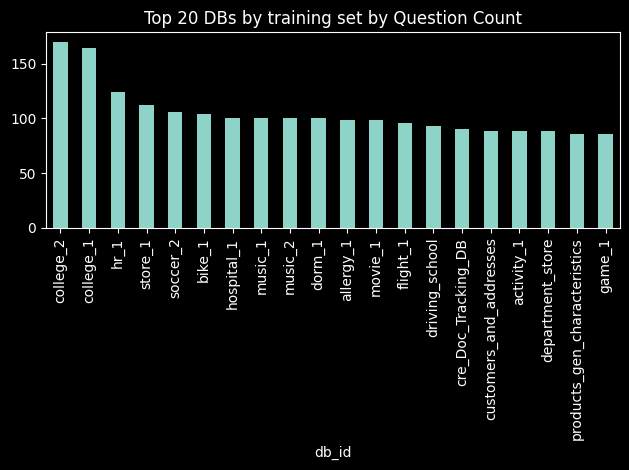

In [20]:
db_counts = train_df['db_id'].value_counts()
print(f"Total unique DBs: {train_df['db_id'].nunique()}")  # ~140 DBs
db_counts.head(20).plot(kind='bar', title='Top 20 DBs by training set by Question Count')
plt.tight_layout()
plt.show()

Total unique DBs: 20


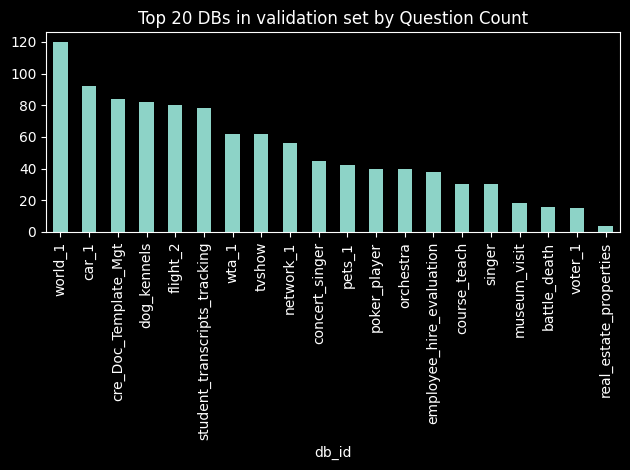

In [21]:
db_counts = validation_df['db_id'].value_counts()
print(f"Total unique DBs: {validation_df['db_id'].nunique()}")  # ~140 DBs
db_counts.head(20).plot(kind='bar', title='Top 20 DBs in validation set by Question Count')
plt.tight_layout()
plt.show()

The database in both the training and validation set are different so that the model is not memorizing stuff and overfitting leading to better generalisation.

# FORMATTING OF THE SCHEMA

In [22]:
#loading the schema of the dbs

spider_tables = load_dataset("richardr1126/spider-schema", split="train")
print(spider_tables)

README.md: 0.00B [00:00, ?B/s]

spider_schema_rows_v2.json: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['db_id', 'Schema (values (type))', 'Primary Keys', 'Foreign Keys'],
    num_rows: 166
})


In [23]:
df= pd.DataFrame(spider_tables)
index = 58
print(f'Database at location {index} is :{df.iloc[58,0]}')

Database at location 58 is :baseball_1


In [24]:
# Verifying that the database in training and validation examples are all represented in the spider_tables

set(df['db_id']) >= set(train_df['db_id']) | set(validation_df['db_id'])

True

In [25]:
print(type(spider_tables))
len(spider_tables)

<class 'datasets.arrow_dataset.Dataset'>


166

In [26]:
print(f"Total unique DBs: {df['db_id'].nunique()}")

Total unique DBs: 166


In [27]:
spider_tables[0]

{'db_id': 'perpetrator',
 'Schema (values (type))': 'perpetrator : Perpetrator_ID (number) , People_ID (number) , Date (text) , Year (number) , Location (text) , Country (text) , Killed (number) , Injured (number) | people : People_ID (number) , Name (text) , Height (number) , Weight (number) , Home Town (text)',
 'Primary Keys': 'perpetrator : Perpetrator_ID | people : People_ID',
 'Foreign Keys': 'perpetrator : People_ID equals people : People_ID'}

In [28]:
len(spider_tables) #although spider_tables type is a dataset arrow, treat it like a list of dicitonaries, where each dictionary is info
# on the schema of the database

166

In [29]:
count =0
for i, schema in enumerate(spider_tables): #shows that spider_tables is like a list that can be iterated over
  count+=1
count

166

In [30]:
print(spider_tables.features)
print("\n--- First entry ---")
print(spider_tables[0])

{'db_id': Value('string'), 'Schema (values (type))': Value('string'), 'Primary Keys': Value('string'), 'Foreign Keys': Value('string')}

--- First entry ---
{'db_id': 'perpetrator', 'Schema (values (type))': 'perpetrator : Perpetrator_ID (number) , People_ID (number) , Date (text) , Year (number) , Location (text) , Country (text) , Killed (number) , Injured (number) | people : People_ID (number) , Name (text) , Height (number) , Weight (number) , Home Town (text)', 'Primary Keys': 'perpetrator : Perpetrator_ID | people : People_ID', 'Foreign Keys': 'perpetrator : People_ID equals people : People_ID'}


In [31]:
# See what fields are available
ex = spider_tables[0]
for k, v in ex.items():
    print(f"\n--- {k} ---")
    print(v)


--- db_id ---
perpetrator

--- Schema (values (type)) ---
perpetrator : Perpetrator_ID (number) , People_ID (number) , Date (text) , Year (number) , Location (text) , Country (text) , Killed (number) , Injured (number) | people : People_ID (number) , Name (text) , Height (number) , Weight (number) , Home Town (text)

--- Primary Keys ---
perpetrator : Perpetrator_ID | people : People_ID

--- Foreign Keys ---
perpetrator : People_ID equals people : People_ID


# SCHEMA CREATION

## Schema lookup

In [32]:
schema_lookup ={}
for row in spider_tables:
  schema_lookup[row['db_id']]= row

schema_lookup['concert_singer']

{'db_id': 'concert_singer',
 'Schema (values (type))': 'stadium : Stadium_ID (number) , Location (text) , Name (text) , Capacity (number) , Highest (number) , Lowest (number) , Average (number) | singer : Singer_ID (number) , Name (text) , Country (text) , Song_Name (text) , Song_release_year (text) , Age (number) , Is_male (others) | concert : concert_ID (number) , concert_Name (text) , Theme (text) , Stadium_ID (text) , Year (text) | singer_in_concert : concert_ID (number) , Singer_ID (text)',
 'Primary Keys': 'stadium : Stadium_ID | singer : Singer_ID | concert : concert_ID | singer_in_concert : concert_ID',
 'Foreign Keys': 'concert : Stadium_ID equals stadium : Stadium_ID | singer_in_concert : Singer_ID equals singer : Singer_ID | singer_in_concert : concert_ID equals concert : concert_ID'}

In [33]:
print(f'Total number of databases: {len(schema_lookup)}')
print('concert_singer' in schema_lookup)

Total number of databases: 166
True


In [34]:
def parse_primary_keys(pk_string):

  pk_map ={}
  # There are database full of tables but has not primary keys at all.
  if not pk_string:
    return pk_map

  for entry in pk_string.split('|'):
    entry = entry.strip()
    table, cols = entry.split(':')

    pk_map[table.strip()] =cols.strip()
  return pk_map

db = 'concert_singer'
map = parse_primary_keys(pk_string = schema_lookup[db]['Primary Keys'])
print(map)

{'stadium': 'Stadium_ID', 'singer': 'Singer_ID', 'concert': 'concert_ID', 'singer_in_concert': 'concert_ID'}


In [35]:
def parse_foreign_keys(fk_string):
    fk_map = {}
    words = fk_string
    fk_string = words.split()
    for i,word in enumerate(fk_string):
        if word =='equals':
            first_table = fk_string[i-3]
            second_table = fk_string[i+1]

            fk_map[(first_table, fk_string[i-1])] = (second_table, fk_string[i+3])


    return fk_map
map = parse_foreign_keys(fk_string = schema_lookup[db]['Foreign Keys'])
print(map)

{('concert', 'Stadium_ID'): ('stadium', 'Stadium_ID'), ('singer_in_concert', 'Singer_ID'): ('singer', 'Singer_ID'), ('singer_in_concert', 'concert_ID'): ('concert', 'concert_ID')}


In [36]:
def format_schema(db_id):
    row = schema_lookup[db_id]
    schema = row['Schema (values (type))']
    pk_map = parse_primary_keys(row['Primary Keys'])
    fk_map = parse_foreign_keys(row['Foreign Keys'])

    schema_lines = []
    for table_info in schema.split('|'):

        table_info = table_info.strip()

        table_name, cols_info = table_info.split(':')
        table_name = table_name.strip()
        cols_info = cols_info.strip()

        # a table can have no primary key.
        pk =''
        if table_name in pk_map:
            pk = pk_map[table_name]

        col_lines = []
        for col_info in cols_info.split(','):

            col_info = col_info.strip()

            col_name = col_info[:col_info.rfind('(')].strip()
            col_type = col_info[col_info.rfind('(')+1 : col_info.rfind(')')].strip()

            # checking if foreign key exist for this column
            fk_found = False
            col_to_find = col_name


            if (table_name, col_to_find) in fk_map:
                mapping = fk_map[(table_name, col_to_find)]
                fk_found = True


            annotations = []

            annotations.append(f'{ col_type}')
            if pk and col_name == pk:
                annotations.append(' PK')
            if fk_found:
                temp = f'{mapping[0]}.{mapping[1]}'
                annotations.append(f' FK -> {temp}')

            annotations = f'- {col_name} ' +  f'({','.join(annotations)})'

            col_lines.append(annotations)
        col_lines = '\n'.join(col_lines)
        schema_lines.append(f'# Table: {table_name} \n## Columns:\n{col_lines}')
    s = '\n\n'.join(schema_lines)
    schema_lookup[db_id]['format_schema'] = s

    return s

db_id = db
s = format_schema(db_id)

print(s)

# Table: stadium 
## Columns:
- Stadium_ID (number, PK)
- Location (text)
- Name (text)
- Capacity (number)
- Highest (number)
- Lowest (number)
- Average (number)

# Table: singer 
## Columns:
- Singer_ID (number, PK)
- Name (text)
- Country (text)
- Song_Name (text)
- Song_release_year (text)
- Age (number)
- Is_male (others)

# Table: concert 
## Columns:
- concert_ID (number, PK)
- concert_Name (text)
- Theme (text)
- Stadium_ID (text, FK -> stadium.Stadium_ID)
- Year (text)

# Table: singer_in_concert 
## Columns:
- concert_ID (number, PK, FK -> concert.concert_ID)
- Singer_ID (text, FK -> singer.Singer_ID)


In [37]:
schema_table= pd.DataFrame(spider_tables)
schema_table['format_schema'] = df['db_id'].apply(format_schema)

In [38]:
longest_schema = max(schema_table['format_schema'],key= len)
approx_tokens = longest_schema.split()
print(f'length of the longest schema separated by words is: {len(approx_tokens)}')

length of the longest schema separated by words is: 1243


In [39]:
shortest_schema = min(schema_table['format_schema'],key= len)
approx_tokens = shortest_schema.split()
len(approx_tokens)

33

# LOADING MODEL

## Understanding Rotational Position Embedding

[RoPE](https://docs.google.com/document/d/1acdbby4rbNF8yIvz4B9exZkia4XXGKlvJoop8TNyaJw/edit?usp=sharing)

In [40]:
import psutil

ram = psutil.virtual_memory()
print(f"Total RAM in CPU     : {ram.total/1e9:.1f} GB")
print(f"Available RAM in CPU: {ram.available/1e9:.1f} GB")
print(f"Used RAM     : {ram.used/1e9:.1f} GB")

Total RAM in CPU     : 33.7 GB
Available RAM in CPU: 31.7 GB
Used RAM     : 1.4 GB


In [41]:
import torch
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))  # should say Tesla P100
    print(torch.cuda.device_count())

True
Tesla T4
2


Above command is for anyone who wants to finetune a LLM. Though above code, we are installing a specialised set of libraries designed for PEFT (Parameter efficient fine tuning) and Quantization.
## Core engines

* transformers by Huggingface: ultimate library for downloading and running pretrained models
* accelerate: handles the movement of training across available hardwares. It handles the movement of tensor between CPU and GPU w/o writing the device allocation code

## Memory savers
* bitsandbytes: Unlocks quantization, converts 16bit model to 4 bit weights so it can fit small GPU;s VRAM. [Process of conversion](https://docs.google.com/document/d/1KWbP5Fob9UTyesJRxd09FKyLaZT29utNNUPYHOwbGL0/edit?usp=sharing)
* peft (Parameter Efficient Fine Tuning): This is what actually creates the $A$ and $B$ low-rank matrices we talked about earlier! It freezes the 4-bit base model and injects the trainable LoRA layers

## Fine Tuning Wrapper
* trl( Transformer Reinforcement Learning): [What is wrapper and what does trl do](https://docs.google.com/document/d/1maHPmdxABUpXq38AOpel-6qO7lmBNklzoRozx9UWRro/edit?tab=t.0)

## Transformers Library

These are the absolute standard tools you need to load an LLM like Phi-2 or Llama 3 for text generation and fine-tuning.

Notice how most of these start with the word "Auto"? That goes back to what we just talked about regarding "wrappers." Instead of you having to figure out the exact math classes for Phi-2 specifically, the "Auto" classes automatically read the model's name and do the heavy lifting for you

* Autotokenizer: Hugging Face automatically downloads the exact dictionary and rules that the Phi-2 creators used to train it.[.eos_token](https://docs.google.com/document/d/1YThD3wZ93_K38LxSwDIFk4_O6SrQyn9Mo2z20Aj0dlc/edit?usp=sharing)
* [AutoModelForCausalLM](https://docs.google.com/document/d/1fo5HTByWJdmNP_WFATlUknFNpJsWGYWWaTtI4qRWWYE/edit?usp=sharing): Microsoft has trained the model to learn the embeddings of the words in the text, now we can use these embeddings to 
  * generate next word, code completion
  * output a single number or category (for sentiment analysis,or spam detection (AutoModelForSequenceClassification is used for this)
* Autoconfig: Every model has a JSON file sitting on the Hugging Face Hub called config.json. This file contains the exact blueprint of the model: how many layers it has, the dimension size of the vectors, the number of attention heads, etc.
**Why use it?** You use AutoConfig if you want to inspect or change the blueprint before loading the model. For example, if you wanted to change Phi-2's max sequence length from 2048 to something else before building it!
*  BitsAndBytesConfig: This is the configuration tool from the bitsandbytes library that we just discussed when talking about 4-bit memory!
**Why use it?** This is where you write the settings to tell the GPU, "Hey, load this massive 2.7-billion-parameter Phi-2 model, but squeeze it down into 4-bit storage so it fits in my smaller VRAM."

# LOADING LLAMA 8.1

In [42]:
from unsloth import FastLanguageModel
import torch

# Load model and tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name   = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length = 2048,
    dtype        = None,
    load_in_4bit = True,
)

# Apply LoRA adapters
model = FastLanguageModel.get_peft_model(
    model,
    r            = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha   = 16,
    lora_dropout = 0,
    bias         = "none",
    use_gradient_checkpointing = 'unsloth',
    random_state = 42,
    use_rslora   = False,
    loftq_config = None,
)

print(f"Memory used: {model.get_memory_footprint()/1e9:.2f} GB")
model.print_trainable_parameters()

/tmp/ipykernel_23/1830332589.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.
Unsloth 2026.4.8 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Memory used: 5.76 GB
trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


In [43]:


# 1. Count how many GPUs PyTorch sees
num_gpus = torch.cuda.device_count()
print(f"Total GPUs detected: {num_gpus}\n")

# 2. Loop through every detected GPU
for i in range(num_gpus):
    # Get properties of the specific GPU (like its name and total capacity)
    props = torch.cuda.get_device_properties(i)
    total_mem = props.total_memory / 1e9
    
    # Check how much memory is actively allocated right now
    allocated_mem = torch.cuda.memory_allocated(i) / 1e9
    
    # Check how much PyTorch is reserving (caching) from the OS
    reserved_mem = torch.cuda.memory_reserved(i) / 1e9
    
    print(f"--- GPU {i}: {props.name} ---")
    print(f"  Total Memory    : {total_mem:.2f} GB")
    print(f"  Allocated Memory: {allocated_mem:.2f} GB")
    print(f"  Reserved Memory : {reserved_mem:.2f} GB")
    print(f"  Available Memory: {(total_mem - allocated_mem):.2f} GB\n")

Total GPUs detected: 2

--- GPU 0: Tesla T4 ---
  Total Memory    : 15.64 GB
  Allocated Memory: 5.91 GB
  Reserved Memory : 5.94 GB
  Available Memory: 9.72 GB

--- GPU 1: Tesla T4 ---
  Total Memory    : 15.64 GB
  Allocated Memory: 0.04 GB
  Reserved Memory : 0.06 GB
  Available Memory: 15.60 GB



In [44]:
# Grab the very first parameter in the model's memory
first_param = next(model.parameters())

# Print its data type
print(f"The model is actually loaded in: {first_param.dtype}")

The model is actually loaded in: torch.float16


4-bit storage → dequantize to fp16 → matmul in fp16 → output in fp16

The LoRA adapter weights are in fp16/fp32
The LoRA matrices (A and B) that you're actually training are small and kept in fp16 or fp32 — not quantized. This is fine because they're tiny (~1-2% of total parameters). Gradients flow only through these adapters, never back into the frozen 4-bit base weights.

[table displaying the above](https://docs.google.com/document/d/15SSxpjEEiwDO2bXmR9sP-HNYB3mF-ypVIlpp61oyuoc/edit?usp=sharing)

# CREATING Full text 

takes in the format schema from the spider_tables database and the query and question from the dataset to create a prompt

In [45]:
print(f"Memory used: {model.get_memory_footprint()/1e9:.2f} GB")
print(f"GPU allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"GPU remaining: {(16 - torch.cuda.memory_allocated()/1e9):.2f} GB")

Memory used: 5.76 GB
GPU allocated: 5.91 GB
GPU remaining: 10.09 GB


# CREATING Full text 

takes in the format schema from the spider_tables database and the query and question from the dataset to create a prompt

In [46]:
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(
    tokenizer,
    chat_template = 'llama', # change this to the right chat_template name
)

In [47]:
def build_prompt( schema_lookup, index, dataset, inference = False ):

    df = dataset
    prompt = ''

    db_id = df['db_id'][index]
    question = df['question'][index]
    schema = schema_lookup[db_id]['format_schema']
    
    prompt = f"""<|start_header_id|>system<|end_header_id|>

Convert the natural language question to SQL using the schema below. Use SQLite syntax and SQLite functions only.{tokenizer.eos_token}<|start_header_id|>user<|end_header_id|>

### Schema:
{schema}

### Question:
{question + tokenizer.eos_token}"""

    if inference == False:
        query = df['query'][index]
        text = prompt+ f"""<|start_header_id|>assistant<|end_header_id|>

{query + tokenizer.eos_token}"""
        
        return {'text':text}
    return{'text': prompt}
    

train_df = pd.DataFrame(dataset['train'])
validation_df = pd.DataFrame(dataset['validation'])

text = build_prompt( schema_lookup, index =0,dataset = validation_df, inference = False )
print(text)

{'text': '<|start_header_id|>system<|end_header_id|>\n\nConvert the natural language question to SQL using the schema below. Use SQLite syntax and SQLite functions only.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n### Schema:\n# Table: stadium \n## Columns:\n- Stadium_ID (number, PK)\n- Location (text)\n- Name (text)\n- Capacity (number)\n- Highest (number)\n- Lowest (number)\n- Average (number)\n\n# Table: singer \n## Columns:\n- Singer_ID (number, PK)\n- Name (text)\n- Country (text)\n- Song_Name (text)\n- Song_release_year (text)\n- Age (number)\n- Is_male (others)\n\n# Table: concert \n## Columns:\n- concert_ID (number, PK)\n- concert_Name (text)\n- Theme (text)\n- Stadium_ID (text, FK -> stadium.Stadium_ID)\n- Year (text)\n\n# Table: singer_in_concert \n## Columns:\n- concert_ID (number, PK, FK -> concert.concert_ID)\n- Singer_ID (text, FK -> singer.Singer_ID)\n\n### Question:\nHow many singers do we have?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nSELECT c

# Train and Validation set

## Deleting longer text from train_dataset

In [48]:
from datasets import Dataset

def build_all_prompts(df, schema_lookup):
    texts = []
    skipped = 0
    for i in range(len(df)):
        result = build_prompt(schema_lookup, i, df, inference=False)
        tokens = tokenizer(
            result['text'],
            truncation=False,
            padding=False,
            add_special_tokens=False
        )
        if len(tokens['input_ids']) <= 2048:
            texts.append(result)
        else:
            skipped += 1
    print(f"Skipped {skipped} examples over 2048 tokens")
    return Dataset.from_list(texts)

train_dataset = build_all_prompts(train_df, schema_lookup)
val_dataset   = build_all_prompts(validation_df, schema_lookup)

Skipped 82 examples over 2048 tokens
Skipped 0 examples over 2048 tokens


In [49]:
sample = train_dataset[0]
tokens = tokenizer(sample['text'], return_tensors = 'pt', add_special_tokens = False)
tokens

{'input_ids': tensor([[128006,   9125, 128007,    271,  12281,    279,   5933,   4221,   3488,
            311,   8029,   1701,    279,  11036,   3770,     13,   5560,  29434,
          20047,    323,  29434,   5865,   1193,     13, 128009, 128006,    882,
         128007,    271,  14711,  12824,    512,      2,   6771,     25,   9476,
            720,    567,  54673,    512,     12,   6011,   3533,    320,   4174,
             11,  25864,    340,     12,   4076,    320,   1342,    340,     12,
          35386,    320,   1342,    340,     12,  65175,    320,   4174,    340,
             12,  28368,   1265,   1702,  91387,    320,   4174,    340,     12,
          16610,   2135,   7256,   5633,    320,   4174,    696,      2,   6771,
             25,   2010,    720,    567,  54673,    512,     12,   2010,   3533,
            320,   4174,     11,  25864,    340,     12,    836,    320,   1342,
            340,     12,   9405,   4486,    320,   1342,    340,     12,   4325,
            32

In [50]:
tokenizer('i love you')

{'input_ids': [128000, 72, 3021, 499], 'attention_mask': [1, 1, 1, 1]}

In [51]:
# print(f'eos_token is: {tokenizer.eos_token}')

# # Understanding tokeniztion, padding, end of sentence, labels managements

# tokenizer.pad_token =  "<|finetune_right_pad_id|>"
# tokenizer.padding_side = 'right'

# A = tokenizer(['I am the god of the new world', 'We love you'],
#              padding = True,
#              return_tensors = 'pt'
#              )
# print(A)



# token_id = tokenizer.eos_token_id
# print(token_id)
# token_string = tokenizer.decode(token_id)
# print(token_string)



# prompt = ['select * from students', 'select name from teachers where id =1']

# encoded_output = tokenizer( prompt,
#              padding = True,
#              return_tensors = 'pt'
#              )
# print(encoded_output)
# print('-----------------------------------')

# for i, query in enumerate(prompt):
#     prompt[i]+= tokenizer.eos_token

# encoded_output = tokenizer( prompt,
#              padding = True,
#              return_tensors = 'pt'
#              )
# print(encoded_output)

# TRAINING ARGUMENTS

## Cosine lr

Look at my copy.

# SAVING STRATEGY
My aim: ok, i want something like this, i want to run the model and check validation loss every step, but i want to save only the best 3 models with the least validation loss. so as the training loop advances through the steps, we keep the updated best 3 models. is this possible.

Yes, this is absolutely possible and is a standard best practice in model training. The `Trainer` is designed to handle exactly this "rolling" leaderboard of checkpoints.

To achieve this, you need to change your `TrainingArguments` to shift from **Time-based saving** (every 10 steps) to **Performance-based saving** (based on loss).

### The Configuration Change

Here is the specific setup you need to add to your `TrainingArguments`:

```python
training_args = TrainingArguments(
    # ... your existing batch and lr settings ...
    
    evaluation_strategy="steps",     # Run evaluation at intervals
    eval_steps=1,                    # Check validation loss every single step
    
    save_strategy="steps",           # Enable saving at intervals
    save_steps=1,                    # Consider saving every single step
    
    save_total_limit=3,              # CRITICAL: Only keep the best 3 folders on disk
    
    load_best_model_at_end=True,      # Tells the trainer to track the "Best" models
    metric_for_best_model="eval_loss",# The metric to decide what is "best"
    greater_is_better=False,         # False because we want the LOWEST loss
)
```

### How the "Rolling Leaderboard" Works
Once you hit `trainer.train()`, the following logic takes over:

1.  **Step 1:** The model trains, evaluates, and calculates a loss of **1.39**. The Trainer saves `checkpoint-1`.
2.  **Step 2:** Loss is **1.38**. This is better. The Trainer saves `checkpoint-2`.
3.  **Step 3:** Loss is **1.37**. Better again. The Trainer saves `checkpoint-3`.
4.  **Step 4 (The Swap):** Loss is **1.36**. Since `save_total_limit=3`, the Trainer looks at its 4 current candidates (1, 2, 3, and the new 4). It sees that `checkpoint-1` has the worst loss. **It automatically deletes the folder for `checkpoint-1` and replaces it with `checkpoint-4`.**
5.  **Step 5 (The Rejection):** If at Step 5 the loss goes **UP** to 1.40, the Trainer will still save it temporarily, but because it is worse than your current top 3, it will be deleted immediately to stay under your limit of 3.



### A Warning on Kaggle Disk Space
Even though you are only keeping 3 models, remember that a "checkpoint" is not just the 5.56 GB model weights. It also includes:
* **The Optimizer State:** For AdamW, this is roughly 2x the size of your trainable parameters.
* **The Scheduler State:** A few KBs.
* **The RNG State:** To ensure reproducibility.

Since you are using LoRA, your trainable parameters are small (a few MBs), but the `Trainer` often saves the **full model weights** in each checkpoint folder unless specifically configured otherwise. 

**Pro-Tip:** If you see "Disk Space Exceeded," you can add `save_only_model=True` to your arguments. This prevents the Trainer from saving the massive optimizer states, saving you gigabytes of space per checkpoint.

***

By setting `load_best_model_at_end=True`, when the training finishes, the `trainer` will automatically load the weights from the absolute best of those 3 checkpoints back into your `model` object, so you are ready for inference immediately. 

**Would you like to see how to point your inference script to these saved checkpoint folders to compare their SQL outputs manually?**

In [52]:
from trl import SFTTrainer, SFTConfig


training_args=SFTConfig(
    output_dir="./outputs",
    per_device_train_batch_size=1,
    per_device_eval_batch_size = 8,
    gradient_accumulation_steps=8,
    warmup_steps=50,
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,                  # T4 doesn't support bf16
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=3,
    optim="paged_adamw_8bit",         # saves memory vs full adamw
    seed=42,
    report_to="none",           # set to "wandb" if you want tracking
    max_seq_length=2048,
    dataset_text_field="text",  # the field in your dataset that has the formatted prompt
    disable_tqdm = False,
    lr_scheduler_type="cosine",
    load_best_model_at_end = True ,       # Tells the trainer to track the "Best" models
    metric_for_best_model = 'eval_loss',  # The metric to decide what is "best"
    greater_is_better = False,             # False because we want the LOWEST loss
    save_only_model=True,
    gradient_checkpointing = True,
    gradient_checkpointing_kwargs={"use_reentrant": False},  # needed for unsloth
    
)

In [53]:
len(train_dataset)

6918

In [54]:
from unsloth.chat_templates import train_on_responses_only
from transformers import EarlyStoppingCallback

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args= training_args,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=10)], # stop if eval_loss doesn't improve for 3 evals (3*eval_steps = 3*50 = 150.)
)

# Apply response-only masking after trainer is constructed
trainer = train_on_responses_only(
    trainer,
    instruction_part="<|start_header_id|>user<|end_header_id|>\n\n",
    response_part="<|start_header_id|>assistant<|end_header_id|>\n\n",
)

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/6918 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/1034 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map (num_proc=8):   0%|          | 0/6918 [00:00<?, ? examples/s]

Filter (num_proc=8):   0%|          | 0/6918 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/1034 [00:00<?, ? examples/s]

Filter (num_proc=8):   0%|          | 0/1034 [00:00<?, ? examples/s]

In [55]:
# To release stale memory
gc.collect()
torch.cuda.empty_cache()

In [56]:
# Directly inspect the first example's labels after collation
sample = train_dataset[0]  # definitely the first example

# Manually tokenize and collate it
inputs = tokenizer(
    sample['text'],
    return_tensors='pt',
    truncation=True,
    max_length=2048,
    add_special_tokens=False
)

# Check where -100 masking ends in the labels
# train_on_responses_only works on the collated batch labels
# so use the dataloader but fix the seed first
import torch
torch.manual_seed(0)
batch = next(iter(trainer.get_train_dataloader()))
labels    = batch['labels'][0]
input_ids = batch['input_ids'][0]

# Find first non -100 position
first_real = (labels != -100).nonzero()[0].item()
print("Token before masking ends:", tokenizer.decode(input_ids[first_real - 1]))
print("First token with real loss:", tokenizer.decode(input_ids[first_real]))

# Also print a window around the boundary
print("\nBoundary context:")
print(tokenizer.decode(input_ids[first_real-5 : first_real+5]))

Token before masking ends: 


First token with real loss: SELECT

Boundary context:
<|eot_id|><|start_header_id|>assistant<|end_header_id|>

SELECT t1.store_name


In [57]:
train_output = trainer.train()
print(train_output)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,918 | Num Epochs = 3 | Total steps = 2,595
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
200,0.107145,0.266102
400,0.228791,0.276682
600,0.146373,0.276936
800,0.063790,0.280545
1000,0.054216,0.311492
1200,0.077732,0.310941
1400,0.009240,0.326031
1600,0.027589,0.320023
1800,0.009194,0.378285
2000,0.011488,0.384248


Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-1200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-1400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-1600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-1800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-2000/tokenizer_config.json.
Unsl

TrainOutput(global_step=2200, training_loss=0.0765787142691393, metrics={'train_runtime': 39173.2542, 'train_samples_per_second': 0.53, 'train_steps_per_second': 0.066, 'total_flos': 2.917671885533184e+17, 'train_loss': 0.0765787142691393})


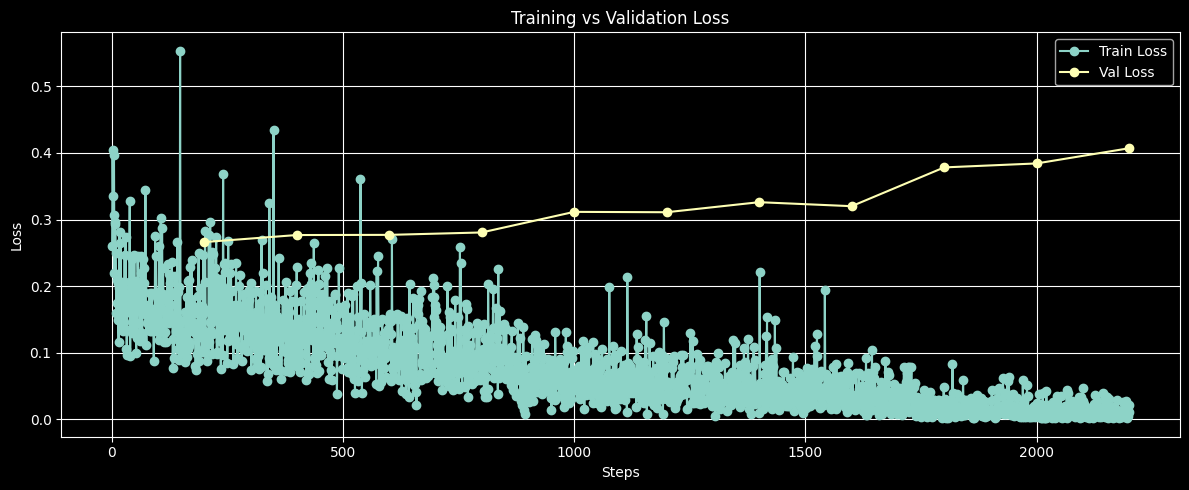

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract logs from trainer
logs = trainer.state.log_history

# Separate train and val logs
train_logs = [l for l in logs if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [l for l in logs if 'eval_loss' in l]

train_steps = [l['step'] for l in train_logs]
train_loss  = [l['loss'] for l in train_logs]

eval_steps  = [l['step'] for l in eval_logs]
eval_loss   = [l['eval_loss'] for l in eval_logs]

# Plot
plt.figure(figsize=(12, 5))
plt.plot(train_steps, train_loss, label='Train Loss', marker='o')
plt.plot(eval_steps,  eval_loss,  label='Val Loss',   marker='o')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png")
plt.show()

## Checkpoints

In [59]:
# Sort eval logs by loss
eval_df = pd.DataFrame(eval_logs)[['step', 'eval_loss']]
eval_df = eval_df.sort_values('eval_loss')
print(eval_df.head(10))

# Top 3 best checkpoints
top3_steps = eval_df.head(3)['step'].tolist()
print(f"\nTop 3 checkpoints: {top3_steps}")
print(f"Best checkpoint  : step {top3_steps[0]}")

   step  eval_loss
0   200   0.266102
1   400   0.276682
2   600   0.276936
3   800   0.280545
5  1200   0.310941
4  1000   0.311492
7  1600   0.320023
6  1400   0.326031
8  1800   0.378285
9  2000   0.384248

Top 3 checkpoints: [200, 400, 600]
Best checkpoint  : step 200


In [60]:
import os

checkpoints = [d for d in os.listdir("/kaggle/working/outputs/") if "checkpoint-" in d]
print(f"The surviving Top-3 checkpoints are: {checkpoints}")

The surviving Top-3 checkpoints are: ['checkpoint-200', 'checkpoint-2000', 'checkpoint-2200']
